In [1]:
!pip install pandas
!pip install os
import pandas as pd
import os



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement os (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for os


### mergng 12 months of sales of data into a single file


In [2]:

df =pd.read_csv("./Sales_Data/Sales_April_2019.csv")

files = [file for file in os.listdir('./Sales_Data/')]

all_months_data = pd.DataFrame()

for file in files:
    df =pd.read_csv("./Sales_Data/" + file)
    all_months_data = pd.concat([all_months_data, df])

all_months_data.to_csv("all_data.csv", index= False)



Read in updated dataframe


In [3]:
all_data = pd.read_csv("all_data.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


add some column, drop row of NAN


In [4]:
nan_df = all_data[all_data.isna().any(axis=1)]
nan_df.head()
all_data = all_data.dropna(how='all') 
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


In [5]:
all_data['Month'] = all_data['Order Date'].str[0:2]
all_data['Month'] = pd.to_numeric(all_data['Month'], errors="coerce").astype("Int64")
all_data.head()


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4


### adding sales column, our aim is to get earn by month
#### to get sales, we mul price each and quantity ordered but first convert both to numbers




In [6]:
all_data= all_data[all_data['Quantity Ordered']!= 'Quantity Ordered']
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'])
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'])

In [7]:
all_data['Sales'] = all_data['Price Each'] * all_data['Quantity Ordered']
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99


##### Question 1: WHat was the best month for sales? How much was earned that month?

In [8]:
result = all_data.groupby('Month').sum()


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


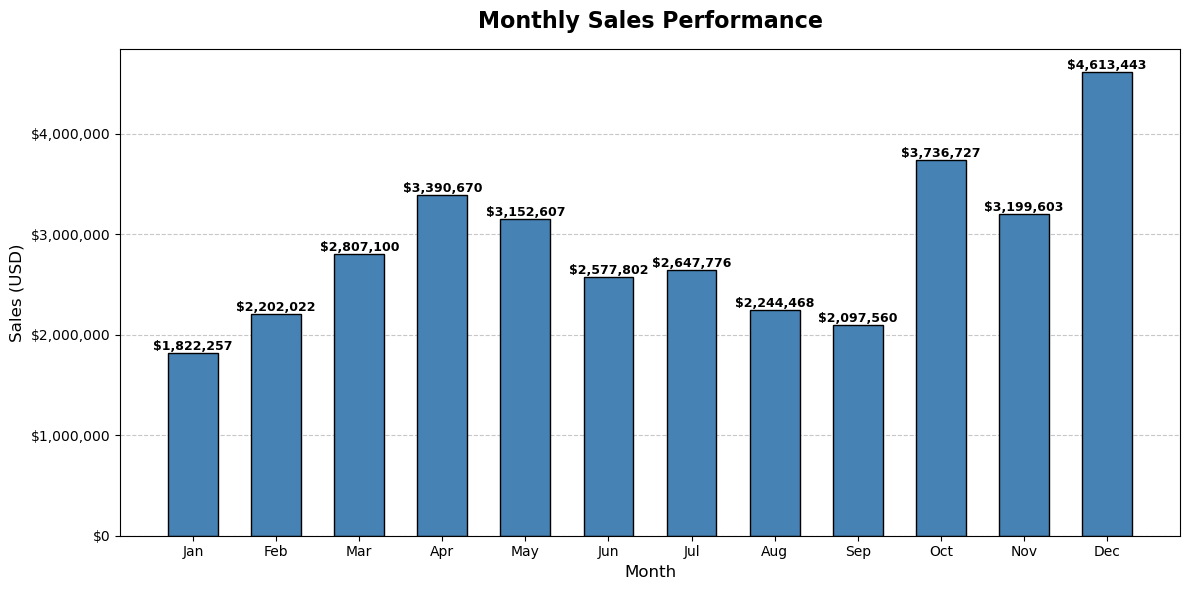

In [9]:
!pip install matplotlib
import matplotlib.pyplot as plt

months = range(1, 13)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(months, result['Sales'], color='steelblue', edgecolor='black', width=0.6)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'${height:,.0f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# Labels and title
ax.set_title('Monthly Sales Performance', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Sales (USD)', fontsize=12)
ax.set_xticks(months)
ax.set_xticklabels(month_labels)

# Format y-axis as currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### Q2 what city has the highest number of sales?

In [10]:
### split by COMMA
### the state can become overlapping, so diff by state
def get_state(address):
    return address.split(',')[2].split(' ')[1]


all_data['City'] = all_data['Purchase Address'].apply(lambda x: x.split(',')[1].strip() + ' ' + get_state(x))


all_data.head(10)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas TX
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston MA
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles CA
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles CA
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles CA
6,176562,USB-C Charging Cable,1,11.95,04/29/19 13:03,"381 Wilson St, San Francisco, CA 94016",4,11.95,San Francisco CA
7,176563,Bose SoundSport Headphones,1,99.99,04/02/19 07:46,"668 Center St, Seattle, WA 98101",4,99.99,Seattle WA
8,176564,USB-C Charging Cable,1,11.95,04/12/19 10:58,"790 Ridge St, Atlanta, GA 30301",4,11.95,Atlanta GA
9,176565,Macbook Pro Laptop,1,1700.00,04/24/19 10:38,"915 Willow St, San Francisco, CA 94016",4,1700.00,San Francisco CA
10,176566,Wired Headphones,1,11.99,04/08/19 14:05,"83 7th St, Boston, MA 02215",4,11.99,Boston MA


In [11]:
city_sales = all_data.groupby('City')['Sales'].sum()

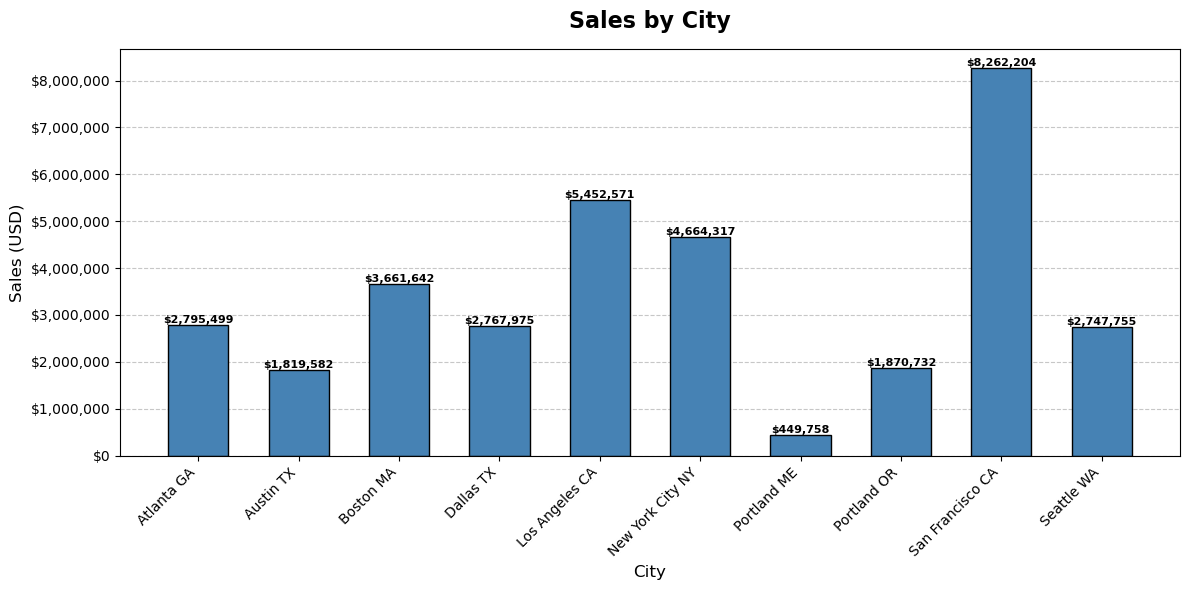

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(city_sales.index, city_sales.values, color='steelblue', edgecolor='black', width=0.6)

# Value labels on top
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'${height:,.0f}',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

ax.set_title('Sales by City', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Sales (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### what time should we display ads to maxi, likelihood of customer's buying

In [13]:
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])

C:\Users\😘\AppData\Local\Temp\ipykernel_17136\3842191188.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])


In [14]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas TX
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston MA
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles CA
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles CA
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles CA


In [15]:
all_data['Hour'] = all_data['Order Date'].dt.hour
all_data['Minute'] = all_data['Order Date'].dt.minute

In [16]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour,Minute
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas TX,8,46
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston MA,22,30
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles CA,14,38
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles CA,14,38
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles CA,9,27


In [17]:
hours = [hour for hour, df in all_data.groupby('Hour')]


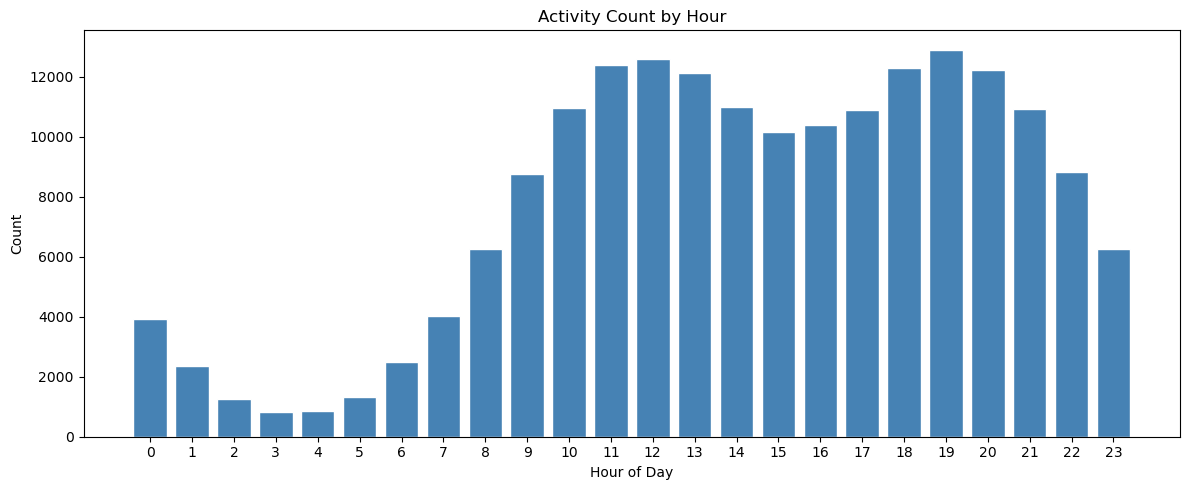

In [18]:
hourly_counts = all_data.groupby('Hour').count().iloc[:, 0]  # get first column as counts

plt.figure(figsize=(12, 5))
plt.bar(hourly_counts.index, hourly_counts.values, color='steelblue', edgecolor='white')

plt.title('Activity Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.xticks(range(0, 24))  # show all 24 hours on x-axis
plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


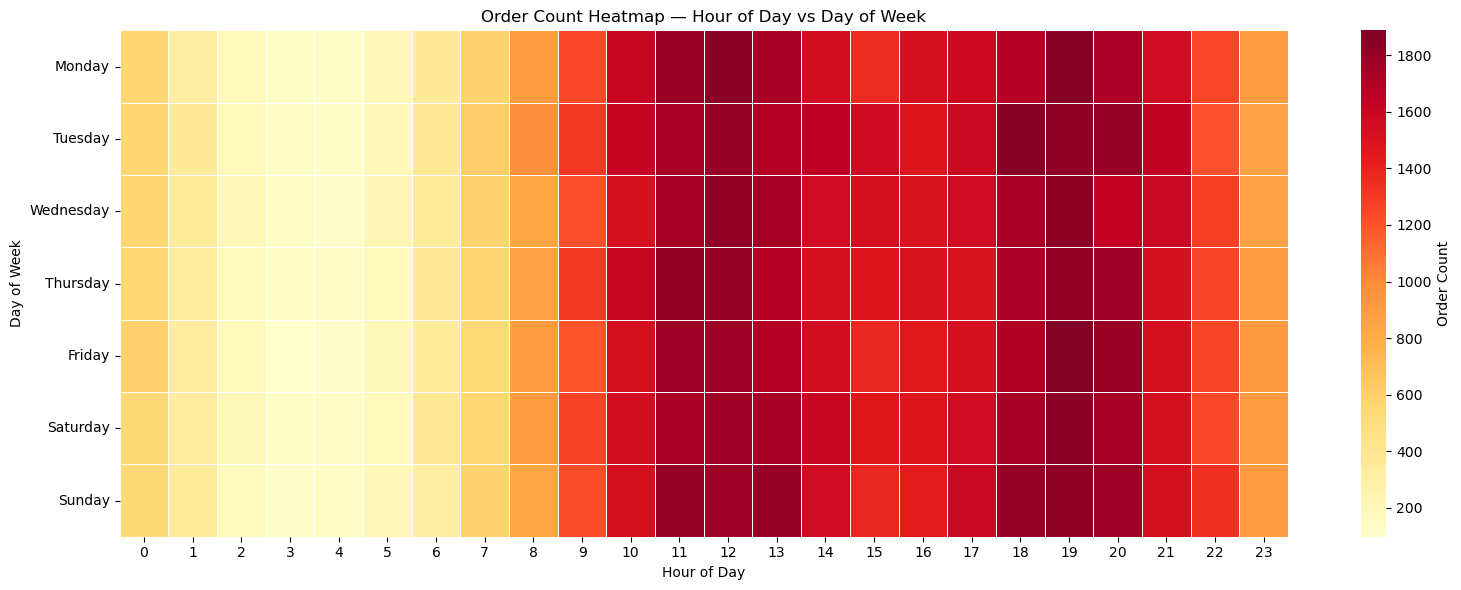

In [19]:

!pip install seaborn
import seaborn as sns


# Extract hour and day of week from Order Date
all_data['Hour'] = pd.to_datetime(all_data['Order Date']).dt.hour
all_data['Day'] = pd.to_datetime(all_data['Order Date']).dt.day_name()

# Pivot table: rows = Day, cols = Hour
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = all_data.groupby(['Day', 'Hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)  # order days Mon–Sun

# Plot
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.5,
    annot=False,
    fmt='d',
    cbar_kws={'label': 'Order Count'}
)

plt.title('Order Count Heatmap — Hour of Day vs Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

#### Best time to put an ads is afternoon and evening, thats whwn people are at break in work, school or at home 

##### q4: whatproducts are most often sold together?

In [20]:
all_data['Product'].unique().tolist()

['USB-C Charging Cable',
 'Bose SoundSport Headphones',
 'Google Phone',
 'Wired Headphones',
 'Macbook Pro Laptop',
 'Lightning Charging Cable',
 '27in 4K Gaming Monitor',
 'AA Batteries (4-pack)',
 'Apple Airpods Headphones',
 'AAA Batteries (4-pack)',
 'iPhone',
 'Flatscreen TV',
 '27in FHD Monitor',
 '20in Monitor',
 'LG Dryer',
 'ThinkPad Laptop',
 'Vareebadd Phone',
 'LG Washing Machine',
 '34in Ultrawide Monitor']

In [21]:
#filter by order id
df = all_data[all_data['Order ID'].duplicated(keep=False)]
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour,Minute,Day
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles CA,14,38,Friday
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles CA,14,38,Friday
18,176574,Google Phone,1,600.00,2019-04-03 19:42:00,"20 Hill St, Los Angeles, CA 90001",4,600.00,Los Angeles CA,19,42,Wednesday
19,176574,USB-C Charging Cable,1,11.95,2019-04-03 19:42:00,"20 Hill St, Los Angeles, CA 90001",4,11.95,Los Angeles CA,19,42,Wednesday
30,176585,Bose SoundSport Headphones,1,99.99,2019-04-07 11:31:00,"823 Highland St, Boston, MA 02215",4,99.99,Boston MA,11,31,Sunday


In [22]:
df['Grouped']= df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
df = df[['Order ID', 'Grouped']].drop_duplicates()
df.head(10)

C:\Users\😘\AppData\Local\Temp\ipykernel_17136\918186483.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grouped']= df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))


,Order ID,Grouped
3,176560,"Google Phone,Wired Headphones"
18,176574,"Google Phone,USB-C Charging Cable"
30,176585,"Bose SoundSport Headphones,Bose SoundSport Hea..."
32,176586,"AAA Batteries (4-pack),Google Phone"
119,176672,"Lightning Charging Cable,USB-C Charging Cable"
129,176681,"Apple Airpods Headphones,ThinkPad Laptop"
138,176689,"Bose SoundSport Headphones,AAA Batteries (4-pack)"
189,176739,"34in Ultrawide Monitor,Google Phone"
225,176774,"Lightning Charging Cable,USB-C Charging Cable"
233,176781,"iPhone,Lightning Charging Cable"


In [23]:
from itertools import combinations
from collections import  Counter

In [24]:
count = Counter()

for row in df['Grouped']:
    row_list = row.split(',')
    count.update(Counter(combinations(row_list, 2)))

for key, value in count.most_common(10):
    print(key, value)

('iPhone', 'Lightning Charging Cable') 1005
('Google Phone', 'USB-C Charging Cable') 987
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 414
('Vareebadd Phone', 'USB-C Charging Cable') 361
('iPhone', 'Apple Airpods Headphones') 360
('Google Phone', 'Bose SoundSport Headphones') 220
('USB-C Charging Cable', 'Wired Headphones') 160
('Vareebadd Phone', 'Wired Headphones') 143
('Lightning Charging Cable', 'Wired Headphones') 92


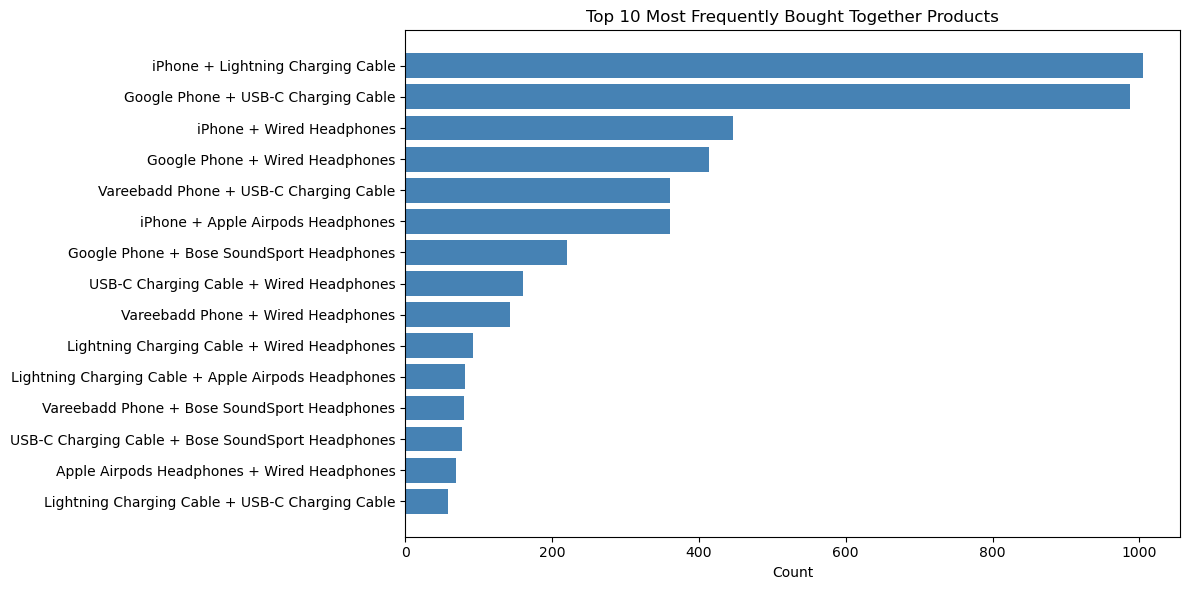

In [26]:
# Get top 10 pairs
top_pairs = count.most_common(15)

# Unpack
labels = [f"{a} + {b}" for (a, b), _ in top_pairs]
values = [v for _, v in top_pairs]

# Plot
plt.figure(figsize=(12, 6))
plt.barh(labels, values, color='steelblue')
plt.xlabel('Count')
plt.title('Top 10 Most Frequently Bought Together Products')
plt.gca().invert_yaxis()  # highest bar on top
plt.tight_layout()
plt.show()

#### q5: what product sold the most? why do you think it sold the most?


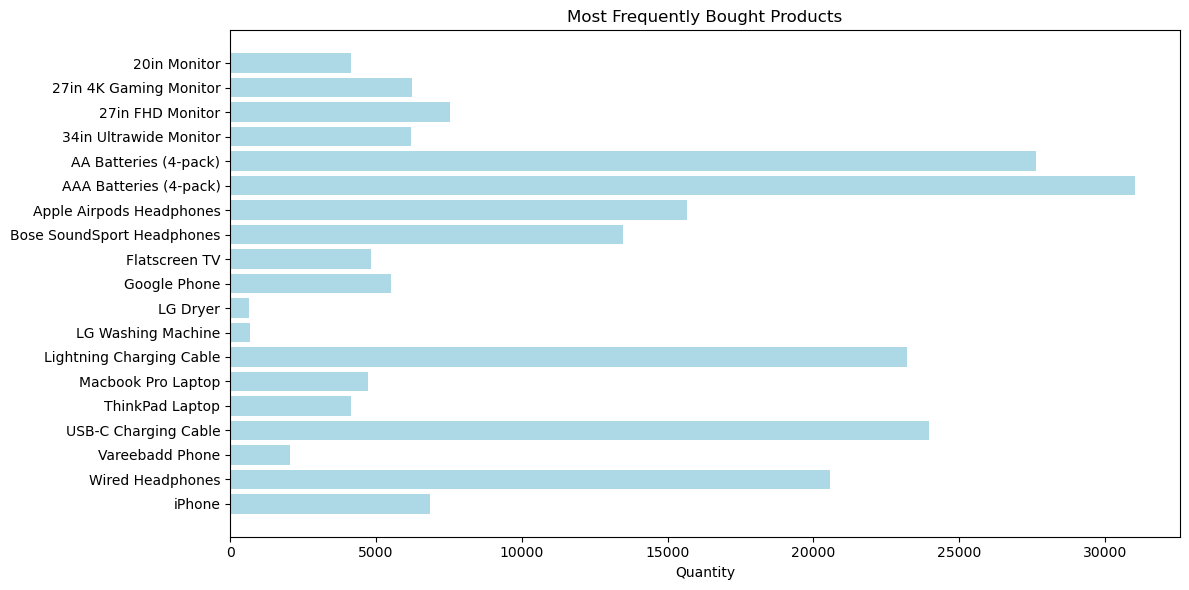

In [33]:
product_group = all_data.groupby('Product')

quantity_ordered = product_group.sum(numeric_only=True)['Quantity Ordered']

products = [product for product, df in product_group]

# Plot
plt.figure(figsize=(12, 6))
plt.barh(products, quantity_ordered, color='lightblue')
plt.xlabel('Quantity')
plt.title('Most Frequently Bought Products')
plt.gca().invert_yaxis()  # highest bar on top
plt.tight_layout()
plt.show()

#### A better graph

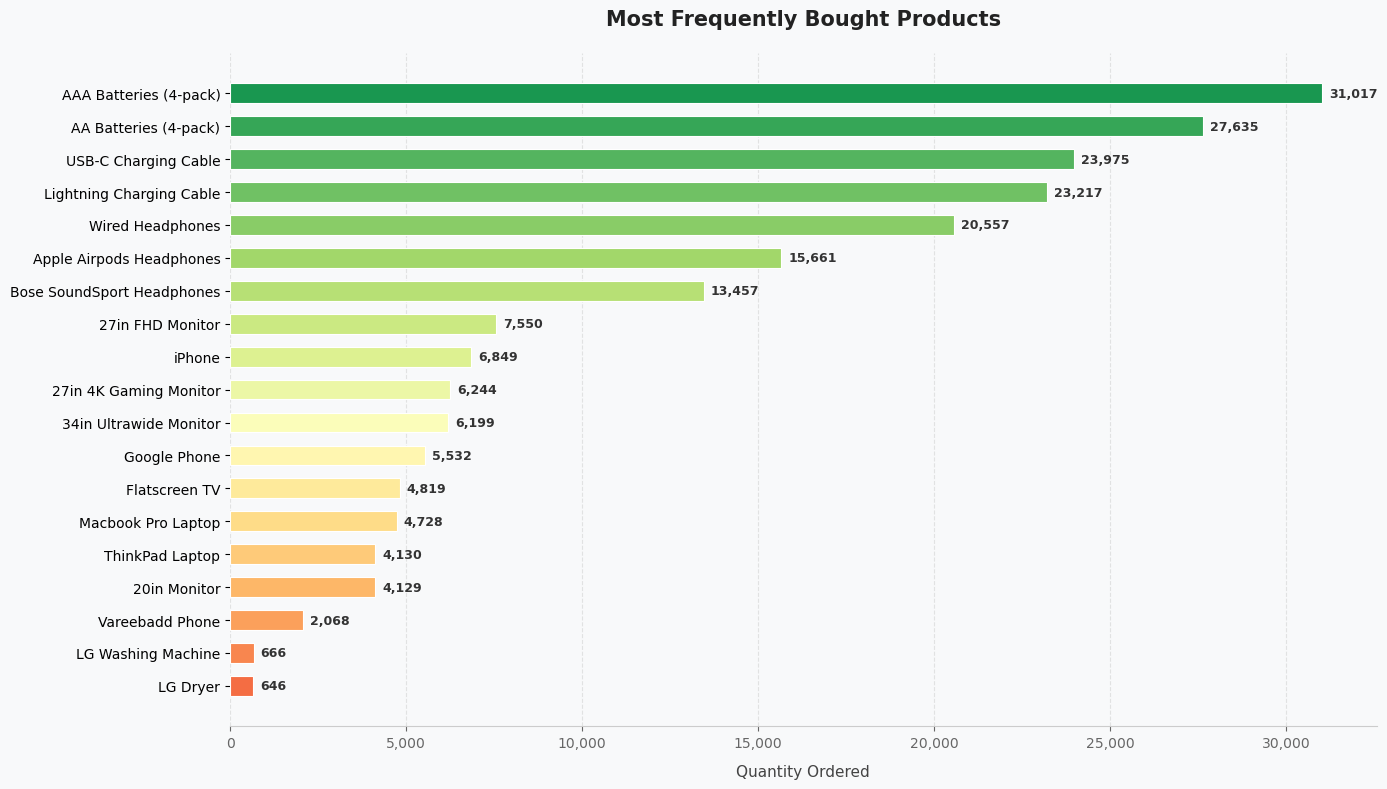

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

product_group = all_data.groupby('Product')
quantity_ordered = product_group.sum(numeric_only=True)['Quantity Ordered'].sort_values()

products = list(quantity_ordered.index)
values = list(quantity_ordered.values)

# Color gradient based on value
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(products)))

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(products, values, color=colors, edgecolor='white', linewidth=0.8, height=0.6)

# Value labels at end of each bar
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', ha='left', fontsize=9, fontweight='bold', color='#333333')

# Styling
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', colors='#666666')
ax.set_xlabel('Quantity Ordered', fontsize=11, color='#444444', labelpad=10)
ax.set_title('Most Frequently Bought Products', fontsize=15, fontweight='bold',
             color='#222222', pad=20)

# Subtle vertical gridlines
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

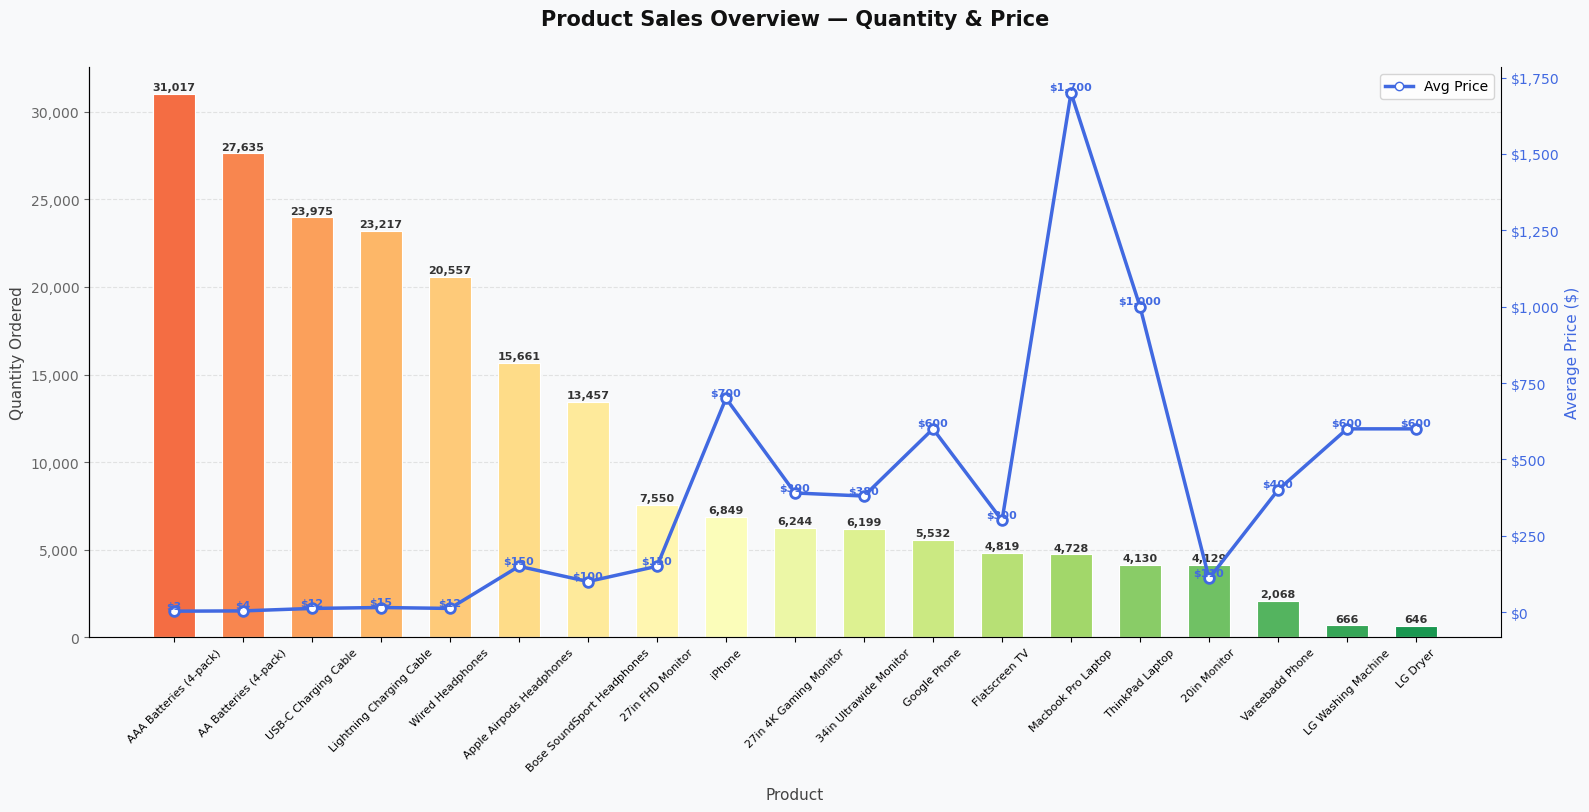

In [36]:
product_group = all_data.groupby('Product')
quantity_ordered = product_group.sum(numeric_only=True)['Quantity Ordered'].sort_values(ascending=False)
prices = all_data.groupby('Product').mean(numeric_only=True)['Price Each']

# Align prices to sorted quantity order
prices_aligned = prices[quantity_ordered.index]

products = list(quantity_ordered.index)
values = list(quantity_ordered.values)
price_values = list(prices_aligned.values)

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(products)))

fig, ax1 = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#f8f9fa')
ax1.set_facecolor('#f8f9fa')

# --- Bar chart: Quantity ---
bars = ax1.bar(products, values, color=colors, edgecolor='white', linewidth=0.8, width=0.6, zorder=2)

for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#333333')

ax1.set_xlabel('Product', fontsize=11, color='#444444', labelpad=10)
ax1.set_ylabel('Quantity Ordered', fontsize=11, color='#444444')
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', colors='#666666')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#cccccc')
ax1.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax1.set_axisbelow(True)

# --- Line chart: Price (second y-axis) ---
ax2 = ax1.twinx()
ax2.plot(products, price_values, color='royalblue', linewidth=2.5,
         marker='o', markersize=7, markerfacecolor='white',
         markeredgecolor='royalblue', markeredgewidth=2, zorder=3, label='Avg Price')

for i, (prod, val) in enumerate(zip(products, price_values)):
    ax2.text(i, val + 8, f'${val:,.0f}', ha='center', fontsize=8,
             color='royalblue', fontweight='bold')

ax2.set_ylabel('Average Price ($)', fontsize=11, color='royalblue')
ax2.tick_params(axis='y', colors='royalblue')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.spines['top'].set_visible(False)

# --- Legend ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='royalblue', linewidth=2.5, marker='o',
           markerfacecolor='white', markeredgecolor='royalblue', label='Avg Price')
]
ax1.legend(legend_elements, ['Avg Price'], loc='upper right', fontsize=10)

fig.suptitle('Product Sales Overview — Quantity & Price', fontsize=15,
             fontweight='bold', color='#111111', y=1.01)
plt.tight_layout()
plt.show()